# Indian Sign Language Recognition



*   https://keras.io/examples/keras_recipes/better_knowledge_distillation/



## Import Libraries

In [ ]:
!pip uninstall tensorflow
!pip install tensorflow

Found existing installation: tensorflow 2.15.0
Uninstalling tensorflow-2.15.0:
  Would remove:
    /usr/local/bin/estimator_ckpt_converter
    /usr/local/bin/import_pb_to_tensorboard
    /usr/local/bin/saved_model_cli
    /usr/local/bin/tensorboard
    /usr/local/bin/tf_upgrade_v2
    /usr/local/bin/tflite_convert
    /usr/local/bin/toco
    /usr/local/bin/toco_from_protos
    /usr/local/lib/python3.10/dist-packages/tensorflow-2.15.0.dist-info/*
    /usr/local/lib/python3.10/dist-packages/tensorflow/*
Proceed (Y/n)? y
y
Y
Y
  Successfully uninstalled tensorflow-2.15.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 589.8/589.8 MB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 9.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 9.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 9.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 9.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from scipy import signal
from keras.models import Sequential, load_model
from keras.layers import TimeDistributed,Conv1D,AveragePooling1D,Flatten,LSTM,Dense,BatchNormalization,Dropout
#from keras.utils.vis_utils import plot_model
from tensorflow.keras.utils import plot_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,classification_report

import tempfile
import os
import zipfile
import time

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path1 = r'/content/drive/MyDrive/HGR_KD_share/teacher_models/'

## Load Data

In [ ]:
file_path = r'/content/drive/MyDrive/HGR_KD_share/' # r'/content/drive/MyDrive/my/HGR/HGR_KD_share/'#
emg = np.load(file_path+'datagen2_emgDom_100signs10subj.npy');
acc = np.load(file_path+'datagen2_accDom_100signs10subj.npy');
gyr = np.load(file_path+'datagen2_gyrDom_100signs10subj.npy');
y_true_all = np.load(file_path+'datagen2_y_true_100signs10subj.npy'); #list(map(str, y_true))
y_true = y_true_all[:,0]
y=np.vstack((y_true,range(0,len(y_true)))).transpose();
chN=3;ax=3;
seglenE = 3000;# int(np.round(1.25*fs[0])); # number of samples to downsample to
seglenA = 400;# int(np.round(1.25*fs[1])); # number of samples to downsample to
n_steps=10;n_lengthE=300; n_lengthA=40;

In [ ]:
emg = emg.reshape((emg.shape[0],chN, seglenE));
emg1 = signal.resample(emg, seglenA, t=None, axis=2);
emg = np.transpose(emg,axes=(0,2,1));
emg1 = np.transpose(emg1,axes=(0,2,1));

acc = acc.reshape((acc.shape[0],chN*ax, seglenA));
acc = np.transpose(acc,axes=(0,2,1));

gyr = gyr.reshape((gyr.shape[0],chN*ax, seglenA));
gyr = np.transpose(gyr,axes=(0,2,1));

#Single feature matrix
X = np.concatenate((emg1,acc,gyr),axis=2)
# Reshape
X = X.reshape((X.shape[0],n_steps, n_lengthA,chN+chN*ax*2));
emg = emg.reshape((emg.shape[0],n_steps, n_lengthE,chN));
acc = acc.reshape((acc.shape[0],n_steps, n_lengthA,chN*ax));
gyr = gyr.reshape((gyr.shape[0],n_steps, n_lengthA,chN*ax));
X.shape,y.shape

((20000, 10, 40, 21), (20000, 2))

In [ ]:
# Split 70-30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y_true)
train_idx = y_train[:,1];   y_train = y_train[:,0]
test_idx = y_test[:,1];     y_test = y_test[:,0]
emg_train = emg[train_idx,:,:,:];
emg_test = emg[test_idx,:,:,:];
acc_train = acc[train_idx,:,:,:];
acc_test = acc[test_idx,:,:,:];
gyr_train = gyr[train_idx,:,:,:];
gyr_test = gyr[test_idx,:,:,:];
del y, emg1, X,emg,acc,gyr

In [ ]:
# Convert labels to categorical

y_train = keras.utils.to_categorical(y_train)
y_test = keras.utils.to_categorical(y_test)
y_test1 = np.argmax(y_test, axis=1)
y_train1 = np.argmax(y_train, axis=1)

In [ ]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)
print(y_train1.shape, y_test1.shape)

(14000, 10, 40, 21) (6000, 10, 40, 21)
(14000, 100) (6000, 100)
(14000,) (6000,)


## Model function

In [ ]:
def create_model(lstm_units):
  model = Sequential()
  model.add(TimeDistributed(Conv1D(filters=12, kernel_size=7, activation='sigmoid'), input_shape=(None,n_length,n_features)))
  model.add(TimeDistributed(AveragePooling1D(pool_size=3)))
  model.add(TimeDistributed(Conv1D(filters=24, kernel_size=7, activation='sigmoid')))
  model.add(TimeDistributed(AveragePooling1D(pool_size=3)))
  model.add(TimeDistributed(Flatten()))
  model.add(LSTM(lstm_units, dropout=0.2, recurrent_dropout=0.2, return_sequences = True))
  model.add(LSTM(lstm_units, dropout=0.2, recurrent_dropout=0.2))
  model.add(BatchNormalization(batch_size = batch_size)) #(batch_size = batch_size)
  model.add(Dropout(0.2))
  model.add(Dense(n_outputs, activation='softmax'))
  return model

In [ ]:
from keras.optimizers import Adam
adam = Adam(learning_rate=0.002)
verbose, epochs, batch_size = 1, 60, 64 #0, 15, 50
n_length, n_features= X_train.shape[2],X_train.shape[3]
n_outputs = y_train.shape[1]
#es = EarlyStopping(monitor = 'val_accuracy',min_delta = 0.0002, patience = 5, verbose = 1,restore_best_weights = True)

## Teacher-Models

In knowledge distillation we assume that the teacher is trained and fixed. Thus, we start by training the teacher model on the training set in the usual way.


In [ ]:
# Create the ensemble of teachers
n_members = 10
teachers = list()
for i in range(n_members):
  teachers.append(create_model(lstm_units=100))

In [ ]:
teachers[0].summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed (TimeDist  (None, None, 34, 12)      1776      
 ributed)                                                        
                                                                 
 time_distributed_1 (TimeDi  (None, None, 11, 12)      0         
 stributed)                                                      
                                                                 
 time_distributed_2 (TimeDi  (None, None, 5, 24)       2040      
 stributed)                                                      
                                                                 
 time_distributed_3 (TimeDi  (None, None, 1, 24)       0         
 stributed)                                                      
                                                                 
 time_distributed_4 (TimeDi  (None, None, 24)          0

In [ ]:
# Train teachers (ensemble members)
from sklearn.utils import resample

history_tens, scores_tens, traintime_tens, testtime_tens = list(),list(),list(),list()
for m in range(n_members):
  # select indexes along rows
  ix = [i for i in range(len(X_train))]
  train_ix = resample(ix, replace=True, n_samples=round(0.85*X_train.shape[0]))
  X_train_resamp, y_train_resamp = X_train[train_ix], y_train[train_ix]

  # Train the teacher model
  teachers[m].compile(
      optimizer=adam,
      loss=keras.losses.CategoricalCrossentropy(from_logits=True),
      metrics=[keras.metrics.CategoricalAccuracy()],
  ) #optimizer=keras.optimizers.Adam(),
  #teachers[m].summary()
  start = time.time()
  hist = teachers[m].fit(X_train_resamp, y_train_resamp, epochs=epochs, batch_size=batch_size, verbose=False, validation_data=(X_test, y_test)) #, epochs=epochs,callbacks=[es]
  traintime_tens.append(time.time() - start)
  hist_ensmem = np.array([hist.history['loss'],hist.history['categorical_accuracy'],hist.history['val_loss'],hist.history['val_categorical_accuracy']])
  history_tens.append(hist_ensmem)
  #teachers[m].save_weights("/content/drive/MyDrive/my/HGR/teacher_models/teach_ens"+str(m)+".h5")

  #evaluate model
  start = time.time()
  [lT,accT] = teachers[m].evaluate(X_test, y_test)
  #accT = hist.history['val_categorical_accuracy'][-1] #
  testtime_tens.append(time.time() - start)
  scores_tens.append(accT)
  print('> teacher%d acc %.3f' %(m,accT))
  print('-....-----------------------------------...-')


temp=np.array(history_tens)
temp=np.reshape(temp,(temp.shape[0],temp.shape[1]*temp.shape[2]))
#pd.DataFrame(temp).to_csv("/content/drive/MyDrive/my/HGR/teacher_models/teach_ens_hist.csv", header=False,index=False)
#pd.Series(traintime_tens).to_csv("/content/drive/MyDrive/my/HGR/teacher_models/teach_ens_traintime.csv", header=False,index=False)
#pd.Series(testtime_tens).to_csv("/content/drive/MyDrive/my/HGR/teacher_models/teach_ens_testtime.csv", header=False,index=False)

/usr/local/lib/python3.10/dist-packages/keras/src/backend.py:5575: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


188/188 [==============================] - 2s 10ms/step - loss: 0.4746 - categorical_accuracy: 0.8690
> teacher0 acc 0.869
-....-----------------------------------...-


StagingError: in user code:

    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1401, in train_function  *
        return step_function(self, iterator)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/optimizers/optimizer.py", line 225, in _update_step_xla  *
        return self._update_step(gradient, variable)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/optimizers/optimizer.py", line 233, in _update_step  **
        raise KeyError(

    KeyError: 'The optimizer cannot recognize variable time_distributed_5/kernel:0. This usually means you are trying to call the optimizer to update different parts of the model separately. Please call `optimizer.build(variables)` with the full list of trainable variables before the training loop or use legacy optimizer `tf.keras.optimizers.legacy.Adam.'


In [ ]:
for m in range(n_members):
  # Load the teacher model
  teachers[m].compile(
      optimizer=adam,
      loss=keras.losses.CategoricalCrossentropy(from_logits=True),
      metrics=[keras.metrics.CategoricalAccuracy()],
  ) #optimizer=keras.optimizers.Adam(),
  teachers[m].evaluate(X_test, y_test)
  teachers[m].load_weights("/content/drive/MyDrive/my/HGR/teacher_models/teach_ens"+str(m)+".h5")

/usr/local/lib/python3.7/dist-packages/tensorflow/python/util/dispatch.py:1082: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a sigmoid or softmax activation and thus does not represent logits. Was this intended?"
  return dispatch_target(*args, **kwargs)


188/188 [==============================] - 2s 9ms/step - loss: 4.6077 - categorical_accuracy: 0.0100


In [ ]:
for m in range(n_members):
  teachers[m].evaluate(X_test, y_test)

188/188 [==============================] - 3s 13ms/step - loss: 0.5216 - categorical_accuracy: 0.8612


In [ ]:
################################33
import matplotlib.pyplot as plt

# Assuming you have your predictions (predicted probabilities) in a numpy array named 'predictions'
# with shape (num_samples, 100) where num_samples is the number of data points and 100 is the number of classes
predictions= teachers[0].predict(X_test)
# Calculate mean accuracy for each class
class_wise_accuracy = predictions.mean(axis=0)

# Calculate standard deviation for each class accuracy (assuming you have ground truth labels)
# Replace 'ground_truth' with your actual ground truth labels array with shape (num_samples,)
class_wise_std = np.std(predictions - ground_truth, axis=0)

# Configure the error bar plot
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
plt.bar(range(100), class_wise_accuracy, yerr=class_wise_std, capsize=7)
plt.xlabel("Class Index")
plt.ylabel("Accuracy")
plt.title("Error Bar Plot of Class-wise Accuracy (100 Classes)")
plt.xticks(range(100), rotation=90)  # Rotate x-axis labels for readability with many classes
plt.tight_layout()
plt.show()

In [ ]:
temp=pd.read_csv("/content/drive/MyDrive/my/HGR/teacher_models/teach_ens_hist.csv", header=None)
history_tens=list()
for m in range(n_members):
  history_tens.append( np.reshape(temp.iloc[m,:].values,(4,epochs)) )
#traintime_tens=pd.read_csv("/content/drive/MyDrive/my/HGR/teacher_models/teach_ens_traintime.csv", header=False,index=False)
#testtime_tens=pd.read_csv("/content/drive/MyDrive/my/HGR/teacher_models/teach_ens_testtime.csv", header=False,index=False)

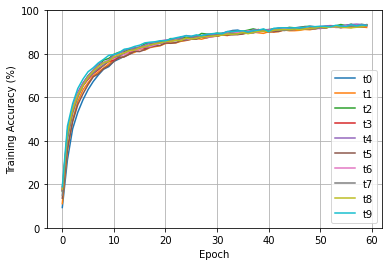

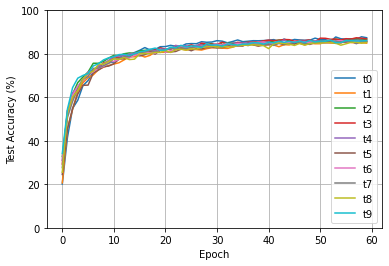

In [ ]:
plt.figure()
for m in range(n_members):
  plt.plot([100*aa for aa in history_tens[m][1,:]],label='t'+str(m))
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy (%)')
plt.grid(True)
plt.ylim((0,100))
plt.legend()
plt.show()

plt.figure()
for m in range(n_members):
  plt.plot([100*aa for aa in history_tens[m][3,:]],label='t'+str(m))
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.grid(True)
plt.ylim((0,100))
plt.legend()
plt.show()

# Single-teacher Single-student

## KD Single-teacher Single-student

In [ ]:
# knowledge distillation (single teacher, single student)
class Distiller1(keras.Model):
    def __init__(self, student, teacher):
        super(Distiller1, self).__init__()
        self.teacher = teacher
        self.student = student

    def compile(
        self,
        optimizer,
        metrics,
        student_loss_fn,
        distillation_loss_fn,
        alpha=0.2,
        temperature=3,
    ):

        super(Distiller1, self).compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        # Unpack data
        x, y = data

        # Forward pass of teacher
        teacher_predictions = self.teacher(x, training=False)

        with tf.GradientTape() as tape:
            # Forward pass of student
            student_predictions = self.student(x, training=True)

            # Compute losses
            student_loss = self.student_loss_fn(y, student_predictions)
            distillation_loss = self.distillation_loss_fn(
                tf.nn.softmax(teacher_predictions / self.temperature, axis=1),
                tf.nn.softmax(student_predictions / self.temperature, axis=1),
            )
            loss = self.alpha * student_loss + (1 - self.alpha) * distillation_loss

        # Compute gradients
        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)

        # Update weights
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        # Update the metrics configured in `compile()`.
        self.compiled_metrics.update_state(y, student_predictions)

        # Return a dict of performance
        results = {m.name: m.result() for m in self.metrics}
        results.update(
            {"student_loss": student_loss, "distillation_loss": distillation_loss}
        )
        return results

    def test_step(self, data):
        # Unpack the data
        x, y = data

        # Compute predictions
        y_prediction = self.student(x, training=False)

        # Calculate the loss
        student_loss = self.student_loss_fn(y, y_prediction)

        # Update the metrics.
        self.compiled_metrics.update_state(y, y_prediction)

        # Return a dict of performance
        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss})
        return results

## Distill to Student Model

In [ ]:
student1 = create_model(lstm_units=50)

In [ ]:
#Distill Student to Teacher
ssst_dist = Distiller1(student=student1, teacher=teachers[1])

ssst_dist.compile(
    optimizer=adam,
    metrics=['accuracy'],
    student_loss_fn=keras.losses.CategoricalCrossentropy(from_logits=True),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.1,
    temperature=3,
)

ssst_hist=ssst_dist.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=True, validation_data=(X_test, y_test)) #, epochs=epochs,callbacks=[es]

Epoch 1/60


/usr/local/lib/python3.7/dist-packages/tensorflow/python/util/dispatch.py:1082: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a sigmoid or softmax activation and thus does not represent logits. Was this intended?"
  return dispatch_target(*args, **kwargs)


219/219 [==============================] - 30s 113ms/step - accuracy: 0.1476 - student_loss: 3.4203 - distillation_loss: 0.0093 - val_accuracy: 0.3840 - val_student_loss: 2.8216
Epoch 2/60
219/219 [==============================] - 24s 107ms/step - accuracy: 0.4021 - student_loss: 2.0081 - distillation_loss: 0.0086 - val_accuracy: 0.5332 - val_student_loss: 1.6796
Epoch 3/60
219/219 [==============================] - 23s 105ms/step - accuracy: 0.4965 - student_loss: 1.6183 - distillation_loss: 0.0085 - val_accuracy: 0.6030 - val_student_loss: 1.4036
Epoch 4/60
219/219 [==============================] - 23s 105ms/step - accuracy: 0.5519 - student_loss: 1.4109 - distillation_loss: 0.0084 - val_accuracy: 0.6550 - val_student_loss: 1.1973
Epoch 5/60
219/219 [==============================] - 23s 106ms/step - accuracy: 0.5817 - student_loss: 1.2902 - distillation_loss: 0.0084 - val_accuracy: 0.6665 - val_student_loss: 1.0973
Epoch 6/60
219/219 [==============================] - 23s 106ms/st

In [ ]:
ssst_hist_arr = np.array([ssst_hist.history['accuracy'],ssst_hist.history['val_accuracy'],ssst_hist.history['student_loss'],ssst_hist.history['val_student_loss'],ssst_hist.history['distillation_loss']])

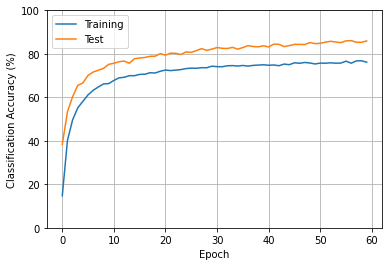

In [ ]:
plt.figure()
plt.plot(100*ssst_hist_arr[0])
plt.plot(100*ssst_hist_arr[1])
plt.xlabel('Epoch')
plt.ylabel('Classification Accuracy (%)')
plt.legend(('Training','Test'))
plt.grid(True)
plt.ylim((0,100))
plt.show()

## Save model

In [ ]:
student1.save_weights("/content/drive/MyDrive/my/HGR/teacher_models/student1_wts.h5")
student1.save('/content/drive/MyDrive/my/HGR/teacher_models/student1.h5')

In [ ]:
ssst_dist.save_weights("/content/drive/MyDrive/my/HGR/teacher_models/ssst_dist.h5")
pd.DataFrame(ssst_hist_arr).to_csv("/content/drive/MyDrive/my/HGR/teacher_models/ssst_hist_arr.csv", header=False,index=False)

## Load Model

In [ ]:
student1=keras.models.load_model('/content/drive/MyDrive/my/HGR/teacher_models/student1.h5')

In [ ]:
# Load ssst_hist_arr
ssst_hist_arr=pd.read_csv("/content/drive/MyDrive/my/HGR/teacher_models/ssst_hist_arr.csv", header=None)
ssst_hist_arr=ssst_hist_arr.values

## Vary alpha

In [ ]:
#del student1a,ssst_dista,ssst_hista

In [ ]:
ssst_hist_arra=list()
alpha_all = [0.1,0.3,0.5]

for alp in alpha_all:
  student1a = create_model(lstm_units=50)

  #Distill Student to Teacher
  ssst_dista = Distiller1(student=student1a, teacher=teachers[0])

  ssst_dista.compile(
      optimizer=adam,
      metrics=['accuracy'],
      student_loss_fn=keras.losses.CategoricalCrossentropy(from_logits=True),
      distillation_loss_fn=keras.losses.KLDivergence(),
      alpha=alp,
      temperature=3,
  )

  ssst_hista=ssst_dista.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=True, validation_data=(X_test, y_test)) #, epochs=epochs,callbacks=[es]
  ssst_hist_arra.append( np.array([ssst_hista.history['accuracy'],ssst_hista.history['val_accuracy'],ssst_hista.history['student_loss'],ssst_hista.history['val_student_loss'],ssst_hista.history['distillation_loss']]) )

Epoch 1/60


/usr/local/lib/python3.7/dist-packages/tensorflow/python/util/dispatch.py:1082: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a sigmoid or softmax activation and thus does not represent logits. Was this intended?"
  return dispatch_target(*args, **kwargs)


219/219 [==============================] - 27s 77ms/step - accuracy: 0.1388 - student_loss: 3.3992 - distillation_loss: 0.0097 - val_accuracy: 0.3443 - val_student_loss: 2.8933
Epoch 2/60
219/219 [==============================] - 15s 70ms/step - accuracy: 0.3574 - student_loss: 2.1542 - distillation_loss: 0.0094 - val_accuracy: 0.4788 - val_student_loss: 1.9044
Epoch 3/60
219/219 [==============================] - 16s 73ms/step - accuracy: 0.4619 - student_loss: 1.7198 - distillation_loss: 0.0093 - val_accuracy: 0.5773 - val_student_loss: 1.5164
Epoch 4/60
219/219 [==============================] - 15s 68ms/step - accuracy: 0.5207 - student_loss: 1.5015 - distillation_loss: 0.0092 - val_accuracy: 0.6113 - val_student_loss: 1.2401
Epoch 5/60
219/219 [==============================] - 15s 69ms/step - accuracy: 0.5583 - student_loss: 1.3538 - distillation_loss: 0.0092 - val_accuracy: 0.6538 - val_student_loss: 1.2673
Epoch 6/60
219/219 [==============================] - 15s 69ms/step - a

In [ ]:
temp=np.array(ssst_hist_arra)
temp=np.reshape(temp,(temp.shape[0],temp.shape[1]*temp.shape[2]))
pd.DataFrame(temp).to_csv("/content/drive/MyDrive/my/HGR/teacher_models/ssst_hist_arr_alpha.csv", header=False,index=False)


In [ ]:
temp=pd.read_csv("/content/drive/MyDrive/my/HGR/teacher_models/ssst_hist_arr_alpha.csv", header=None)
alpha_all = [0.1,0.3,0.5]
ssst_hist_arra=list()
for m in range(len(alpha_all)):
  ssst_hist_arra.append( np.reshape(temp.iloc[m,:].values,(5,epochs)))

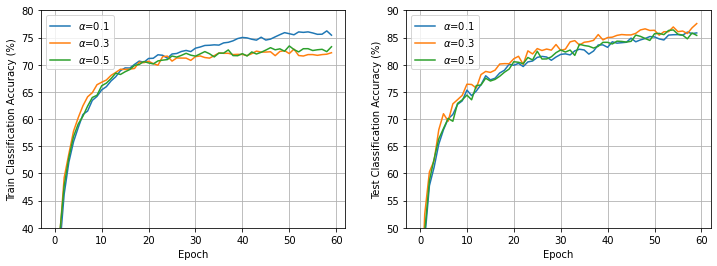

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(121)
for aa in range(len(alpha_all)):
  plt.plot(100*ssst_hist_arra[aa][0])
plt.xlabel('Epoch')
plt.ylabel('Train Classification Accuracy (%)')
plt.legend([r'$\alpha$='+str(alp) for alp in alpha_all])
plt.grid(True)
plt.ylim((40,80))
#plt.show()

plt.subplot(122)
for aa in range(len(alpha_all)):
  plt.plot(100*ssst_hist_arra[aa][1])
plt.xlabel('Epoch')
plt.ylabel('Test Classification Accuracy (%)')
plt.legend([r'$\alpha$='+str(alp) for alp in alpha_all])
plt.grid(True)
plt.ylim((50,90))
plt.show()

## Vary temperature

In [ ]:
del ssst_hist_arra, student1a, ssst_dista, ssst_hista

In [ ]:
ssst_hist_arra=list()
temperature_all = [2,3,5,7]

for temp in temperature_all:
  student1a = create_model(lstm_units=50)

  #Distill Student to Teacher
  ssst_dista = Distiller1(student=student1a, teacher=teachers[0])

  ssst_dista.compile(
      optimizer=adam,
      metrics=['accuracy'],
      student_loss_fn=keras.losses.CategoricalCrossentropy(from_logits=True),
      distillation_loss_fn=keras.losses.KLDivergence(),
      alpha=0.1,
      temperature=temp,
  )

  ssst_hista=ssst_dista.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=True, validation_data=(X_test, y_test)) #, epochs=epochs,callbacks=[es]
  ssst_hist_arra.append( np.array([ssst_hista.history['accuracy'],ssst_hista.history['val_accuracy'],ssst_hista.history['student_loss'],ssst_hista.history['val_student_loss'],ssst_hista.history['distillation_loss']]) )

Epoch 1/60


/usr/local/lib/python3.7/dist-packages/tensorflow/python/util/dispatch.py:1082: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a sigmoid or softmax activation and thus does not represent logits. Was this intended?"
  return dispatch_target(*args, **kwargs)


219/219 [==============================] - 26s 72ms/step - accuracy: 0.1470 - student_loss: 3.4314 - distillation_loss: 0.0018 - val_accuracy: 0.3223 - val_student_loss: 2.7968
Epoch 2/60
219/219 [==============================] - 15s 69ms/step - accuracy: 0.3754 - student_loss: 2.1000 - distillation_loss: 0.0018 - val_accuracy: 0.5083 - val_student_loss: 1.7342
Epoch 3/60
219/219 [==============================] - 15s 69ms/step - accuracy: 0.4766 - student_loss: 1.6859 - distillation_loss: 0.0018 - val_accuracy: 0.5815 - val_student_loss: 1.5768
Epoch 4/60
219/219 [==============================] - 15s 69ms/step - accuracy: 0.5399 - student_loss: 1.4466 - distillation_loss: 0.0018 - val_accuracy: 0.6427 - val_student_loss: 1.3112
Epoch 5/60
219/219 [==============================] - 19s 85ms/step - accuracy: 0.5706 - student_loss: 1.3139 - distillation_loss: 0.0018 - val_accuracy: 0.6582 - val_student_loss: 1.2301
Epoch 6/60
219/219 [==============================] - 16s 73ms/step - a

In [ ]:
temp=np.array(ssst_hist_arra)
temp=np.reshape(temp,(temp.shape[0],temp.shape[1]*temp.shape[2]))
pd.DataFrame(temp).to_csv("/content/drive/MyDrive/my/HGR/teacher_models/ssst_hist_arr_temp.csv", header=False,index=False)

In [ ]:
temp=pd.read_csv("/content/drive/MyDrive/my/HGR/teacher_models/ssst_hist_arr_temp.csv", header=None)
temperature_all = [2,3,5,7]
ssst_hist_arra=list()
for m in range(len(temperature_all)):
  ssst_hist_arra.append( np.reshape(temp.iloc[m,:].values,(5,epochs)) )

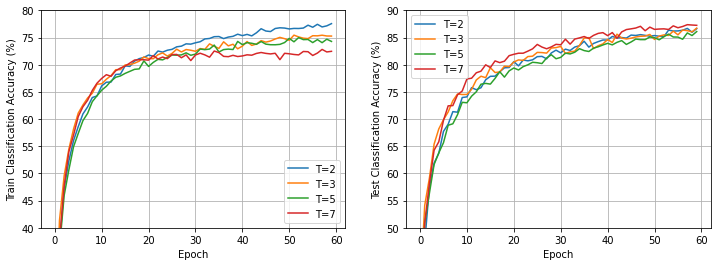

In [ ]:
temperature_all = [2,3,5,7]
plt.figure(figsize=(12,4))
plt.subplot(121)
for aa in range(len(temperature_all)):
  plt.plot(100*ssst_hist_arra[aa][0])
plt.xlabel('Epoch')
plt.ylabel('Train Classification Accuracy (%)')
plt.legend(['T='+str(alp) for alp in temperature_all])
plt.grid(True)
plt.ylim((40,80))
#plt.show()

plt.subplot(122)
for aa in range(len(temperature_all)):
  plt.plot(100*ssst_hist_arra[aa][1])
plt.xlabel('Epoch')
plt.ylabel('Test Classification Accuracy (%)')
plt.legend(['T='+str(alp) for alp in temperature_all])
plt.grid(True)
plt.ylim((50,90))
plt.show()

# Multiple teachers, Single student

## KD Multiple-teachers Single-student

In [ ]:
# knowledge distillation using ensemble of teachers
class DistillerE(keras.Model):
    def __init__(self, student, teacher):
        super(DistillerE, self).__init__()
        self.teacher = teacher
        self.student = student

    def compile(
        self,
        optimizer,
        metrics,
        student_loss_fn,
        distillation_loss_fn,
        alpha=0.1,
        temperature=3,
    ):
        """ Configure the distiller.

        Args:
            optimizer: Keras optimizer for the student weights
            metrics: Keras metrics for evaluation
            student_loss_fn: Loss function of difference between student
                predictions and ground-truth
            distillation_loss_fn: Loss function of difference between soft
                student predictions and soft teacher predictions
            alpha: weight to student_loss_fn and 1-alpha to distillation_loss_fn
            temperature: Temperature for softening probability distributions.
                Larger temperature gives softer distributions.
        """
        super(DistillerE, self).compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        # Unpack data
        x, y = data

        # Forward pass of teacher
        predictions = self.teacher[0](x, training=False)
        for model in self.teacher[1:]:
          logits = model(x, training=False)
          predictions += logits

        teacher_predictions = predictions/len(self.teacher)

        with tf.GradientTape() as tape:
            # Forward pass of student
            student_predictions = self.student(x, training=True)

            # Compute losses
            student_loss = self.student_loss_fn(y, student_predictions)
            distillation_loss = self.distillation_loss_fn(
                tf.nn.softmax(teacher_predictions / self.temperature, axis=1),
                tf.nn.softmax(student_predictions / self.temperature, axis=1),
            )
            loss = self.alpha * student_loss + (1 - self.alpha) * distillation_loss

        # Compute gradients
        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)

        # Update weights
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        # Update the metrics configured in `compile()`.
        self.compiled_metrics.update_state(y, student_predictions)

        # Return a dict of performance
        results = {m.name: m.result() for m in self.metrics}
        results.update(
            {"student_loss": student_loss, "distillation_loss": distillation_loss}
        )
        return results

    def test_step(self, data):
        # Unpack the data
        x, y = data

        # Compute predictions
        y_prediction = self.student(x, training=False)

        # Calculate the loss
        student_loss = self.student_loss_fn(y, y_prediction)

        # Update the metrics.
        self.compiled_metrics.update_state(y, y_prediction)

        # Return a dict of performance
        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss})
        print('... test_step ...')
        print(results)
        return results

## Distill to Student Model

In [ ]:
student2 = create_model(lstm_units=50)

In [ ]:
ssmt_dist =  DistillerE(student=student2, teacher=teachers)

ssmt_dist.compile(
    optimizer=adam,
    metrics=['accuracy'],
    student_loss_fn=keras.losses.CategoricalCrossentropy(from_logits=True),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.1,
    temperature=3,
)

# Distill teacher to student
ssmt_hist=ssmt_dist.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=True, validation_data=(X_test, y_test)) #, epochs=epochs,callbacks=[es]

Epoch 1/60


/usr/local/lib/python3.7/dist-packages/tensorflow/python/util/dispatch.py:1082: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a sigmoid or softmax activation and thus does not represent logits. Was this intended?"
  return dispatch_target(*args, **kwargs)


219/219 [==============================] - ETA: 0s - accuracy: 0.1534 - student_loss: 3.3775 - distillation_loss: 0.0051... test_step ...
{'accuracy': <tf.Tensor 'Identity:0' shape=() dtype=float32>, 'student_loss': <tf.Tensor 'categorical_crossentropy/weighted_loss/value:0' shape=() dtype=float32>}
219/219 [==============================] - 54s 188ms/step - accuracy: 0.1534 - student_loss: 3.3728 - distillation_loss: 0.0051 - val_accuracy: 0.2958 - val_student_loss: 2.8860
Epoch 2/60
219/219 [==============================] - 38s 172ms/step - accuracy: 0.3688 - student_loss: 2.1135 - distillation_loss: 0.0046 - val_accuracy: 0.5030 - val_student_loss: 1.5956
Epoch 3/60
219/219 [==============================] - 37s 171ms/step - accuracy: 0.4580 - student_loss: 1.7207 - distillation_loss: 0.0045 - val_accuracy: 0.5650 - val_student_loss: 1.5051
Epoch 4/60
219/219 [==============================] - 38s 171ms/step - accuracy: 0.5159 - student_loss: 1.5247 - distillation_loss: 0.0044 - va

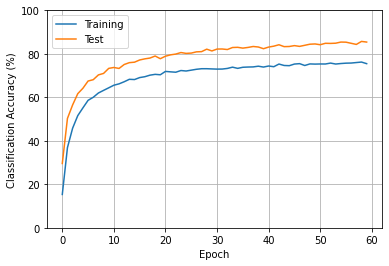

In [ ]:
ssmt_hist_arr = np.array([ssmt_hist.history['accuracy'],ssmt_hist.history['val_accuracy'],ssmt_hist.history['student_loss'],ssmt_hist.history['val_student_loss'],ssmt_hist.history['distillation_loss']])
plt.figure()
plt.plot(100*ssmt_hist_arr[0])
plt.plot(100*ssmt_hist_arr[1])
plt.xlabel('Epoch')
plt.ylabel('Classification Accuracy (%)')
plt.legend(('Training','Test'))
plt.grid(True)
plt.ylim((0,100))
plt.show()

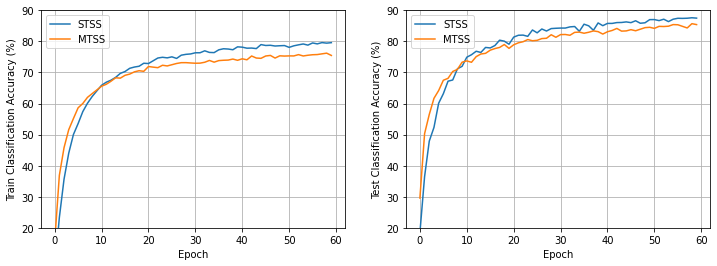

In [ ]:
plt.figure(figsize = (12,4))

plt.subplot(121)
plt.plot(100*ssst_hist_arr[0])
plt.plot(100*ssmt_hist_arr[0])
plt.xlabel('Epoch')
plt.ylabel('Train Classification Accuracy (%)')
plt.legend(('STSS','MTSS'))
plt.grid(True)
plt.ylim((20,90))
#plt.show()

plt.subplot(122)
plt.plot(100*ssst_hist_arr[1])
plt.plot(100*ssmt_hist_arr[1])
plt.xlabel('Epoch')
plt.ylabel('Test Classification Accuracy (%)')
plt.legend(('STSS','MTSS'))
plt.grid(True)
plt.ylim((20,90))
plt.show()

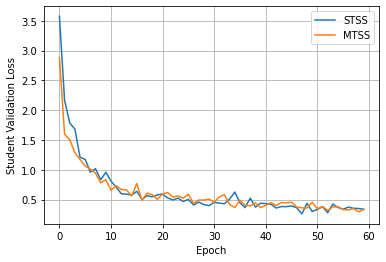

In [ ]:
plt.figure()
plt.plot(ssst_hist_arr[3])
plt.plot(ssmt_hist_arr[3])
plt.xlabel('Epoch')
plt.ylabel('Student Validation Loss')
plt.legend(('STSS','MTSS'))
plt.grid(True)
#plt.ylim((20,90))
plt.show()

In [ ]:
for layer in ssmt_dist.layers:
    wts = layer.get_weights()
    print(wts)

## Save Model

In [ ]:
student2.save('/content/drive/MyDrive/my/HGR/teacher_models/student2.h5')
student2.save_weights("/content/drive/MyDrive/my/HGR/teacher_models/student2_wts.h5")

In [ ]:
ssmt_dist.save_weights("/content/drive/MyDrive/my/HGR/teacher_models/ssmt_dist.h5")
pd.DataFrame(ssmt_hist_arr).to_csv("/content/drive/MyDrive/my/HGR/teacher_models/ssmt_hist_arr.csv", header=False,index=False)

## Load Model

In [ ]:
student2=keras.models.load_model('/content/drive/MyDrive/my/HGR/teacher_models/student2.h5')

OSError: No file or directory found at /content/drive/MyDrive/my/HGR/teacher_models/student2.h5

In [ ]:
# Load ssst_hist_arr
ssmt_hist_arr=pd.read_csv("/content/drive/MyDrive/my/HGR/teacher_models/ssmt_hist_arr.csv", header=None)
ssmt_hist_arr=ssmt_hist_arr.values

In [ ]:
student2.summary()

Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed_55 (TimeD  (None, None, 34, 12)      1776      
 istributed)                                                     
                                                                 
 time_distributed_56 (TimeD  (None, None, 11, 12)      0         
 istributed)                                                     
                                                                 
 time_distributed_57 (TimeD  (None, None, 5, 24)       2040      
 istributed)                                                     
                                                                 
 time_distributed_58 (TimeD  (None, None, 1, 24)       0         
 istributed)                                                     
                                                                 
 time_distributed_59 (TimeD  (None, None, 24)        

In [ ]:
student3 = create_model(lstm_units=25)

In [ ]:
#Distill from Scholar to weak_student
sch_dist1 = Distiller1(student=student3, teacher=student2)

sch_dist1.compile(
    optimizer=adam,
    metrics=['accuracy'],
    student_loss_fn=keras.losses.CategoricalCrossentropy(from_logits=True),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.1,
    temperature=3,
)

sch_hist1=sch_dist1.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=True, validation_data=(X_test, y_test)) #, epochs=epochs,callbacks=[es]

Epoch 1/60


/usr/local/lib/python3.7/dist-packages/tensorflow/python/util/dispatch.py:1082: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a sigmoid or softmax activation and thus does not represent logits. Was this intended?"
  return dispatch_target(*args, **kwargs)


219/219 [==============================] - 42s 166ms/step - accuracy: 0.1091 - student_loss: 3.6077 - distillation_loss: 0.0084 - val_accuracy: 0.2548 - val_student_loss: 3.2083
Epoch 2/60
219/219 [==============================] - 24s 107ms/step - accuracy: 0.2836 - student_loss: 2.4950 - distillation_loss: 0.0078 - val_accuracy: 0.4025 - val_student_loss: 2.1767
Epoch 3/60
219/219 [==============================] - 24s 108ms/step - accuracy: 0.3659 - student_loss: 2.1195 - distillation_loss: 0.0075 - val_accuracy: 0.4810 - val_student_loss: 1.8569
Epoch 4/60
219/219 [==============================] - 24s 112ms/step - accuracy: 0.4089 - student_loss: 1.9227 - distillation_loss: 0.0074 - val_accuracy: 0.5325 - val_student_loss: 1.7669
Epoch 5/60
219/219 [==============================] - 23s 107ms/step - accuracy: 0.4431 - student_loss: 1.7884 - distillation_loss: 0.0073 - val_accuracy: 0.5740 - val_student_loss: 1.4658
Epoch 6/60
219/219 [==============================] - 23s 106ms/st

In [ ]:
student3.save('/content/drive/MyDrive/my/HGR/teacher_models/student3.h5')
student3.save_weights("/content/drive/MyDrive/my/HGR/teacher_models/student3_wts.h5")

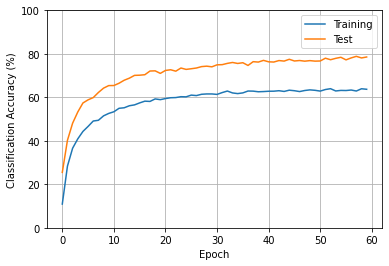

In [ ]:
sch_hist_arr = np.array([sch_hist1.history['accuracy'],sch_hist1.history['val_accuracy'],sch_hist1.history['student_loss'],sch_hist1.history['val_student_loss'],sch_hist1.history['distillation_loss']])
plt.figure()
plt.plot(100*sch_hist_arr[0])
plt.plot(100*sch_hist_arr[1])
plt.xlabel('Epoch')
plt.ylabel('Classification Accuracy (%)')
plt.legend(('Training','Test'))
plt.grid(True)
plt.ylim((0,100))
plt.show()

In [ ]:
sch_dist1.save_weights("/content/drive/MyDrive/my/HGR/teacher_models/sch_dist1.h5")
pd.DataFrame(sch_hist_arr).to_csv("/content/drive/MyDrive/my/HGR/teacher_models/sch_hist_arr.csv", header=False,index=False)

In [ ]:
student3.summary()

Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed_60 (TimeD  (None, None, 34, 12)      1776      
 istributed)                                                     
                                                                 
 time_distributed_61 (TimeD  (None, None, 11, 12)      0         
 istributed)                                                     
                                                                 
 time_distributed_62 (TimeD  (None, None, 5, 24)       2040      
 istributed)                                                     
                                                                 
 time_distributed_63 (TimeD  (None, None, 1, 24)       0         
 istributed)                                                     
                                                                 
 time_distributed_64 (TimeD  (None, None, 24)        

In [ ]:
student4 = create_model(lstm_units=25)

In [ ]:
wsmt_dist =  DistillerE(student=student4, teacher=teachers)

wsmt_dist.compile(
    optimizer=adam,
    metrics=['accuracy'],
    student_loss_fn=keras.losses.CategoricalCrossentropy(from_logits=True),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.1,
    temperature=3,
)

# Distill teacher to student
wsmt_hist=wsmt_dist.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=True, validation_data=(X_test, y_test)) #, epochs=epochs,callbacks=[es]

Epoch 1/60


/usr/local/lib/python3.7/dist-packages/tensorflow/python/util/dispatch.py:1082: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a sigmoid or softmax activation and thus does not represent logits. Was this intended?"
  return dispatch_target(*args, **kwargs)


219/219 [==============================] - ETA: 0s - accuracy: 0.0801 - student_loss: 3.8248 - distillation_loss: 0.0054... test_step ...
{'accuracy': <tf.Tensor 'Identity:0' shape=() dtype=float32>, 'student_loss': <tf.Tensor 'categorical_crossentropy/weighted_loss/value:0' shape=() dtype=float32>}
219/219 [==============================] - 53s 187ms/step - accuracy: 0.0801 - student_loss: 3.8217 - distillation_loss: 0.0054 - val_accuracy: 0.1880 - val_student_loss: 3.3465
Epoch 2/60
219/219 [==============================] - 39s 177ms/step - accuracy: 0.2241 - student_loss: 2.7873 - distillation_loss: 0.0055 - val_accuracy: 0.3452 - val_student_loss: 2.3278
Epoch 3/60
219/219 [==============================] - 39s 177ms/step - accuracy: 0.3209 - student_loss: 2.3403 - distillation_loss: 0.0053 - val_accuracy: 0.4453 - val_student_loss: 1.9591
Epoch 4/60
219/219 [==============================] - 38s 171ms/step - accuracy: 0.3761 - student_loss: 2.0897 - distillation_loss: 0.0052 - va

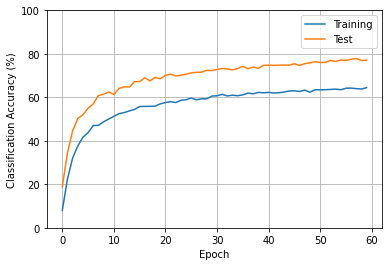

In [ ]:
wsmt_hist_arr = np.array([wsmt_hist.history['accuracy'],wsmt_hist.history['val_accuracy'],wsmt_hist.history['student_loss'],wsmt_hist.history['val_student_loss'],wsmt_hist.history['distillation_loss']])
plt.figure()
plt.plot(100*wsmt_hist_arr[0])
plt.plot(100*wsmt_hist_arr[1])
plt.xlabel('Epoch')
plt.ylabel('Classification Accuracy (%)')
plt.legend(('Training','Test'))
plt.grid(True)
plt.ylim((0,100))
plt.show()

In [ ]:
student4.save('/content/drive/MyDrive/my/HGR/teacher_models/student4.h5')
student4.save_weights("/content/drive/MyDrive/my/HGR/teacher_models/student4_wts.h5")
wsmt_dist.save_weights("/content/drive/MyDrive/my/HGR/teacher_models/wsmt_dist.h5")
pd.DataFrame(wsmt_hist_arr).to_csv("/content/drive/MyDrive/my/HGR/teacher_models/wsmt_hist_arr.csv", header=False,index=False)

In [ ]:
student5 = create_model(lstm_units=25)

In [ ]:
#Distill Student to Teacher
wsst_dist = Distiller1(student=student5, teacher=teachers[1])

wsst_dist.compile(
    optimizer=adam,
    metrics=['accuracy'],
    student_loss_fn=keras.losses.CategoricalCrossentropy(from_logits=True),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.1,
    temperature=3,
)

wsst_hist=wsst_dist.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=True, validation_data=(X_test, y_test)) #, epochs=epochs,callbacks=[es]

Epoch 1/60


/usr/local/lib/python3.7/dist-packages/tensorflow/python/util/dispatch.py:1082: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a sigmoid or softmax activation and thus does not represent logits. Was this intended?"
  return dispatch_target(*args, **kwargs)


219/219 [==============================] - 29s 109ms/step - accuracy: 0.1034 - student_loss: 3.6487 - distillation_loss: 0.0095 - val_accuracy: 0.2248 - val_student_loss: 3.2916
Epoch 2/60
219/219 [==============================] - 23s 106ms/step - accuracy: 0.2772 - student_loss: 2.5367 - distillation_loss: 0.0093 - val_accuracy: 0.4103 - val_student_loss: 1.9730
Epoch 3/60
219/219 [==============================] - 23s 107ms/step - accuracy: 0.3679 - student_loss: 2.1196 - distillation_loss: 0.0093 - val_accuracy: 0.4992 - val_student_loss: 1.5316
Epoch 4/60
219/219 [==============================] - 23s 107ms/step - accuracy: 0.4186 - student_loss: 1.9188 - distillation_loss: 0.0093 - val_accuracy: 0.5490 - val_student_loss: 1.4843
Epoch 5/60
219/219 [==============================] - 23s 106ms/step - accuracy: 0.4500 - student_loss: 1.7800 - distillation_loss: 0.0094 - val_accuracy: 0.5803 - val_student_loss: 1.4206
Epoch 6/60
219/219 [==============================] - 23s 106ms/st

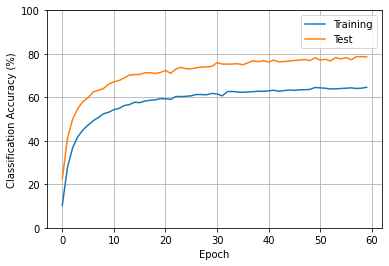

In [ ]:
wsst_hist_arr = np.array([wsst_hist.history['accuracy'],wsst_hist.history['val_accuracy'],wsst_hist.history['student_loss'],wsst_hist.history['val_student_loss'],wsst_hist.history['distillation_loss']])
plt.figure()
plt.plot(100*wsst_hist_arr[0])
plt.plot(100*wsst_hist_arr[1])
plt.xlabel('Epoch')
plt.ylabel('Classification Accuracy (%)')
plt.legend(('Training','Test'))
plt.grid(True)
plt.ylim((0,100))
plt.show()

In [ ]:
student5.save('/content/drive/MyDrive/my/HGR/teacher_models/student5.h5')
student5.save_weights("/content/drive/MyDrive/my/HGR/teacher_models/student5_wts.h5")
wsst_dist.save_weights("/content/drive/MyDrive/my/HGR/teacher_models/wsst_dist.h5")
pd.DataFrame(wsst_hist_arr).to_csv("/content/drive/MyDrive/my/HGR/teacher_models/wsst_hist_arr.csv", header=False,index=False)

# Model Size

https://www.oreilly.com/library/view/tinyml/9781492052036/ch04.html

In [ ]:
import os
import tempfile

In [ ]:
def get_gzipped_model_size(file):
  # Returns size of gzipped model, in bytes.
  _, zipped_file = tempfile.mkstemp('.zip')
  with zipfile.ZipFile(zipped_file, 'w', compression=zipfile.ZIP_DEFLATED) as f:
    f.write(file)

  return os.path.getsize(zipped_file)

In [ ]:
_, KD_keras_file = tempfile.mkstemp('.h5')
tf.keras.models.save_model(teachers[0], KD_keras_file, include_optimizer=False)
print('Saved Teacher Keras model to:', KD_keras_file)
print("Size of Teacher Model: %.2f bytes" % (get_gzipped_model_size(KD_keras_file)))

Saved Teacher Keras model to: /tmp/tmpghr345b0.h5
Size of Teacher Model: 541845.00 bytes


In [ ]:
_, KD_keras_file = tempfile.mkstemp('.h5')
tf.keras.models.save_model(student1, KD_keras_file, include_optimizer=False)
print('Saved Scholar Keras model to:', KD_keras_file)
print("Size of Scholar Model: %.2f bytes" % (get_gzipped_model_size(KD_keras_file)))

Saved Scholar Keras model to: /tmp/tmp5hz4ol7b.h5
Size of Scholar Model: 169635.00 bytes


In [ ]:
_, KD_keras_file = tempfile.mkstemp('.h5')
tf.keras.models.save_model(student3, KD_keras_file, include_optimizer=False)
print('Saved Weak student Keras model to:', KD_keras_file)
print("Size of Weak student Model: %.2f bytes" % (get_gzipped_model_size(KD_keras_file)))

Saved Weak student Keras model to: /tmp/tmpserq45zi.h5
Size of Weak student Model: 66116.00 bytes


In [ ]:
scholar = keras.models.load_model('/content/drive/MyDrive/HGR_KD_share/teacher_models/Copy of student1.h5')
scholar.summary()

Model: "sequential_15"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed_75 (TimeD  (None, None, 34, 12)      1776      
 istributed)                                                     
                                                                 
 time_distributed_76 (TimeD  (None, None, 11, 12)      0         
 istributed)                                                     
                                                                 
 time_distributed_77 (TimeD  (None, None, 5, 24)       2040      
 istributed)                                                     
                                                                 
 time_distributed_78 (TimeD  (None, None, 1, 24)       0         
 istributed)                                                     
                                                                 
 time_distributed_79 (TimeD  (None, None, 24)        

In [ ]:
weak_student = keras.models.load_model('/content/drive/MyDrive/HGR_KD_share/teacher_models/Copy of student3.h5')
weak_student.summary()

Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed_60 (TimeD  (None, None, 34, 12)      1776      
 istributed)                                                     
                                                                 
 time_distributed_61 (TimeD  (None, None, 11, 12)      0         
 istributed)                                                     
                                                                 
 time_distributed_62 (TimeD  (None, None, 5, 24)       2040      
 istributed)                                                     
                                                                 
 time_distributed_63 (TimeD  (None, None, 1, 24)       0         
 istributed)                                                     
                                                                 
 time_distributed_64 (TimeD  (None, None, 24)        

In [ ]:
Teacher = keras.models.load_model('/content/drive/MyDrive/HGR_KD_share/teacher_models/Copy of teach_ens9 (1).h5')
Teacher.summary()

ValueError: No model config found in the file at <tensorflow.python.platform.gfile.GFile object at 0x7de9683f6260>.

In [ ]:
''' Not Working
# Convert the model to the TensorFlow Lite format without quantization
converter = tf.lite.TFLiteConverter.from_keras_model(student1)
tflite_student1 = converter.convert()

# Save the model to disk
open("student1.tflite", "wb").write(tflite_student1)


student1_size = os.path.getsize("student1.tflite")
print("student1 model is %d bytes" % student1)
'''

In [ ]:
scholar_scratch = create_model(lstm_units=50)

In [ ]:
scholar_scratch.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed (TimeDist  (None, None, 34, 12)      1776      
 ributed)                                                        
                                                                 
 time_distributed_1 (TimeDi  (None, None, 11, 12)      0         
 stributed)                                                      
                                                                 
 time_distributed_2 (TimeDi  (None, None, 5, 24)       2040      
 stributed)                                                      
                                                                 
 time_distributed_3 (TimeDi  (None, None, 1, 24)       0         
 stributed)                                                      
                                                                 
 time_distributed_4 (TimeDi  (None, None, 24)          0

In [ ]:
from sklearn.model_selection import KFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import CategoricalAccuracy
import time


# Initialize the KFold cross-validator
kf = KFold(n_splits=5, shuffle=True, random_state=42)

acc_scores = []
train_times = []
test_times = []

# Loop over each fold
for train_index, val_index in kf.split(X_train):
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    # Create a new model instance
    scholar_scratch = create_model(lstm_units=50)

    # Compile the model
    adam = Adam()
    scholar_scratch.compile(
        optimizer=adam,
        loss=CategoricalCrossentropy(from_logits=True),
        metrics=[CategoricalAccuracy()],
    )

    # Train the model
    start = time.time()
    hist = scholar_scratch.fit(X_train_fold, y_train_fold, epochs=epochs, batch_size=batch_size, verbose=False, validation_data=(X_val_fold, y_val_fold))
    traintime_scholar = time.time() - start

    # Evaluate the model
    start = time.time()
    loss, acc = scholar_scratch.evaluate(X_val_fold, y_val_fold, verbose=0)
    testtime_scholar = time.time() - start

    acc_scores.append(acc)
    train_times.append(traintime_scholar)
    test_times.append(testtime_scholar)

    print('> scholar from scratch: acc %.3f, train time %.3f, test time %.3f' % (acc, traintime_scholar, testtime_scholar))

# Average results
print('Average accuracy: %.3f' % np.mean(acc_scores))
print('Average training time: %.3f' % np.mean(train_times))
print('Average testing time: %.3f' % np.mean(test_times))


/usr/local/lib/python3.10/dist-packages/keras/src/backend.py:5575: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


> scholar from scratch: acc 0.846, train time 507.183, test time 1.271


> scholar from scratch: acc 0.833, train time 507.969, test time 1.473


> scholar from scratch: acc 0.849, train time 507.062, test time 1.037


> scholar from scratch: acc 0.838, train time 507.826, test time 1.586


> scholar from scratch: acc 0.836, train time 508.693, test time 1.316
Average accuracy: 0.840
Average training time: 507.747
Average testing time: 1.337


In [ ]:
# K-fold Cross Validation model evaluation
schacc_per_fold,schtraintime,schtesttime=[],[],[]
fold_no = 1
for train, test in kfold.split(inputs, targets):
  scholar_scratch = create_model(lstm_units=50)
  scholar_scratch.compile(
        optimizer=adam,
        loss=keras.losses.CategoricalCrossentropy(from_logits=True),
        metrics=[keras.metrics.CategoricalAccuracy()],
    )
  print(f'\tTraining for fold {fold_no} ...')
  start = time.time()
  hist = scholar_scratch.fit(inputs[train], targets[train], epochs=epochs, batch_size=batch_size, verbose=False, validation_data=(inputs[test], targets[test])) #, epochs=epochs,callbacks=[es]
  traintime_scholar=time.time() - start
  #evaluate model
  start = time.time()
  [lT,accT] = scholar_scratch.evaluate(inputs[test], targets[test])
  testtime_scholar=time.time() - start
  schacc_per_fold.append(accT* 100)
  schtraintime.append(traintime_scholar)
  schtesttime.append(testtime_scholar)
  print('\tscholar from scratch: acc %.3f, train time %d, test time %d' %(accT,traintime_scholar,testtime_scholar))


	Training for fold 1 ...


/usr/local/lib/python3.10/dist-packages/keras/src/backend.py:5575: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


63/63 [==============================] - 1s 15ms/step - loss: 0.2994 - categorical_accuracy: 0.8915


	scholar from scratch: acc 0.891, train time 1412, test time 1


	Training for fold 1 ...


StagingError: in user code:

    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1401, in train_function  *
        return step_function(self, iterator)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/optimizers/optimizer.py", line 225, in _update_step_xla  *
        return self._update_step(gradient, variable)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/optimizers/optimizer.py", line 233, in _update_step  **
        raise KeyError(

    KeyError: 'The optimizer cannot recognize variable time_distributed_15/kernel:0. This usually means you are trying to call the optimizer to update different parts of the model separately. Please call `optimizer.build(variables)` with the full list of trainable variables before the training loop or use legacy optimizer `tf.keras.optimizers.legacy.Adam.'


### Converting to TFLITE Bytes and Acquiring Size of Base Model

In [ ]:
# Convert the model to the TensorFlow Lite format without quantization
#converter = tf.lite.TFLiteConverter.from_keras_model(model1)
#tflite_model = converter.convert()

# Save the model to disk
#open("/content/drive/MyDrive/HGR_DL/minor_RS1_teachermdl.tflite", "wb").write(tflite_model)
#mport os
#basic_model_size = os.path.getsize("/content/drive/MyDrive/HGR_DL/minor_RS1_teachermdl.tflite")
#print("Base Model is %d bytes" % basic_model_size)

_, keras_file = tempfile.mkstemp('.h5')
tf.keras.models.save_model(model1, keras_file, include_optimizer=False)
print('Saved basel model to:', keras_file)



Saved basel model to: /tmp/tmphctl_wq7.h5



## Knowledge Distillation

### Converting to TFLITE Bytes and Acquiring Size of Distilled Model


In [ ]:
# Convert the model to the TensorFlow Lite format without quantization

#converter = tf.lite.TFLiteConverter.from_keras_model(model2)
#tflite_model2 = converter.convert()

# Save the model to disk

#open("/content/drive/MyDrive/HGR_DL/minor_RS1_kdmdl.tflite", "wb").write(tflite_model2)
#import os
#basic_model_size = os.path.getsize("/content/drive/MyDrive/HGR_DL/minor_RS1_kdmdl.tflite")
#print("Distilled Model is %d bytes" % basic_model_size)
import tempfile
import os
_, KD_keras_file = tempfile.mkstemp('.h5')
tf.keras.models.save_model(model2, KD_keras_file, include_optimizer=False)
print('Saved Distilled Keras model to:', KD_keras_file)

Saved Distilled Keras model to: /tmp/tmp13t2gyho.h5


##Model Size

In [ ]:
def get_gzipped_model_size(file):
  # Returns size of gzipped model, in bytes.
  _, zipped_file = tempfile.mkstemp('.zip')
  with zipfile.ZipFile(zipped_file, 'w', compression=zipfile.ZIP_DEFLATED) as f:
    f.write(file)

  return os.path.getsize(zipped_file)

In [ ]:
print("Size of Base Model: %.2f bytes" % (get_gzipped_model_size(keras_file)))


Size of Base Model: 523941.00 bytes


In [ ]:
print("Size of Distilled Model: %.2f bytes" % (get_gzipped_model_size(KD_keras_file)))

Size of Distilled Model: 132157.00 bytes


## Model Accuracy

Base Model Accuracy


In [ ]:
y1_pred = model1.evaluate(X_test, y_test, verbose=0)[1]
print("Base Model Accuracy:","{:.3f}%".format(y1_pred*100))

Base Model Accuracy: 93.417%


Distilled Model Accuracy


In [ ]:
y2_pred = distiller.evaluate(X_test, y_test, verbose=0)[1]
print("Distilled Model Accuracy","{:.3f}%".format(y2_pred*100))

Distilled Model Accuracy 76.517%


Reference:
* https://machinelearningmastery.com/develop-n-gram-multichannel-convolutional-neural-network-sentiment-analysis/
* https://machinelearningmastery.com/how-to-develop-convolutional-neural-network-models-for-time-series-forecasting/
* KD: https://keras.io/examples/vision/knowledge_distillation/
* Ensemble KD: https://machinelearningmastery.com/weighted-average-ensemble-for-deep-learning-neural-networks/